# Biodiversity
## Introduction
In this analysis we'll be diving into National Parks Service data to investigate conservation statuses of endangered species and if there are any patterns or themes to the types of species that become endangered.<br>

## Scope
The goal of this project is to answer the following questions:
- What is the data?
- What is the distribution of species across parks?
- What is the distribution of conservation statuses across species?
- Are certain species more likely to be endangered?

In [1]:
# Importing used libraries
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

# Data
Both data files were provided by Codecademy.com<br>
- `../data/raw/Species_info.csv` - contains data about different species and their conservation status
- `../data/raw/Observations.csv` - holds recorded sightings of different species at several national parks for the past 7 days

<span style="font-size: 80%;">Note: The data for this project is inspired by real data, but is mostly fictional.</span>

### Species Data
The dataset columns are:
- `category` - represents the category of the species (Vascular Plant, Nonvascular Plant, Fish, Amphibian, Reptile, Bird or Mammal)
- `scientific_name` - the species' scientific name
- `common_names` - a list of the species' common names
- `conservation_status` - the conservation status, if the species is is endangered in any way, otherwise is empty. Possible conservation statuses are: **Species of Concern**, **Endangered**, **Threatened** and **In Recovery**.

In [2]:
species_df = pd.read_csv('../data/raw/species_info.csv')
species_df.head()

,category,scientific_name,common_names,conservation_status
0,Mammal,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole,NaN
1,Mammal,Bos bison,"American Bison, Bison",NaN
2,Mammal,Bos taurus,"Aurochs, Aurochs, Domestic Cattle (Feral), Dom...",NaN
3,Mammal,Ovis aries,"Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)",NaN
4,Mammal,Cervus elaphus,Wapiti Or Elk,NaN


In [4]:
species_df.describe()

,category,scientific_name,common_names,conservation_status
count,5824,5824,5824,191
unique,7,5541,5504,4
top,Vascular Plant,Castor canadensis,Brachythecium Moss,Species of Concern
freq,4470,3,7,161


In [12]:
species_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5824 entries, 0 to 5823
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   category             5824 non-null   object
 1   scientific_name      5824 non-null   object
 2   common_names         5824 non-null   object
 3   conservation_status  191 non-null    object
dtypes: object(4)
memory usage: 182.1+ KB


In [6]:
species_df['category'].value_counts()

category
Vascular Plant       4470
Bird                  521
Nonvascular Plant     333
Mammal                214
Fish                  127
Amphibian              80
Reptile                79
Name: count, dtype: int64

In [5]:
species_df['conservation_status'].value_counts()

conservation_status
Species of Concern    161
Endangered             16
Threatened             10
In Recovery             4
Name: count, dtype: int64

### Observations Data
The dataset columns are:
- `scientific_name` - the species' scientific name
- `park_name` - the park in which the observations were made
- `observations` - the number of observations for the past 7 days

In [3]:
observations_df = pd.read_csv('../data/raw/observations.csv')
observations_df.head()

,scientific_name,park_name,observations
0,Vicia benghalensis,Great Smoky Mountains National Park,68
1,Neovison vison,Great Smoky Mountains National Park,77
2,Prunus subcordata,Yosemite National Park,138
3,Abutilon theophrasti,Bryce National Park,84
4,Githopsis specularioides,Great Smoky Mountains National Park,85


In [11]:
observations_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23296 entries, 0 to 23295
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   scientific_name  23296 non-null  object
 1   park_name        23296 non-null  object
 2   observations     23296 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 546.1+ KB


In [15]:
observations_df[['scientific_name', 'park_name']].describe()

,scientific_name,park_name
count,23296,23296
unique,5541,4
top,Myotis lucifugus,Great Smoky Mountains National Park
freq,12,5824


In [16]:
observations_df['park_name'].value_counts()

park_name
Great Smoky Mountains National Park    5824
Yosemite National Park                 5824
Bryce National Park                    5824
Yellowstone National Park              5824
Name: count, dtype: int64

In [13]:
observations_df['observations'].describe()

count    23296.000000
mean       142.287904
std         69.890532
min          9.000000
25%         86.000000
50%        124.000000
75%        195.000000
max        321.000000
Name: observations, dtype: float64

## Distribution of Species
For this analysis we'll be using a single merged dataframe with all the data.

In [20]:
# Create merged dataframe from observations and species
all_df = pd.merge(
    observations_df,
    species_df,
    left_on='scientific_name',
    right_on='scientific_name',
    how= 'outer')
all_df.head()

,scientific_name,park_name,observations,category,common_names,conservation_status
0,Abies bifolia,Bryce National Park,109,Vascular Plant,Rocky Mountain Alpine Fir,NaN
1,Abies bifolia,Yellowstone National Park,215,Vascular Plant,Rocky Mountain Alpine Fir,NaN
2,Abies bifolia,Great Smoky Mountains National Park,72,Vascular Plant,Rocky Mountain Alpine Fir,NaN
3,Abies bifolia,Yosemite National Park,136,Vascular Plant,Rocky Mountain Alpine Fir,NaN
4,Abies concolor,Great Smoky Mountains National Park,101,Vascular Plant,"Balsam Fir, Colorado Fir, Concolor Fir, Silver...",NaN


We can see that there is a great predominance of `Vascular Plants` as a category in the observations.<br>
Looking only at animal species, `Birds` are the main category, followed by `Mammals`.

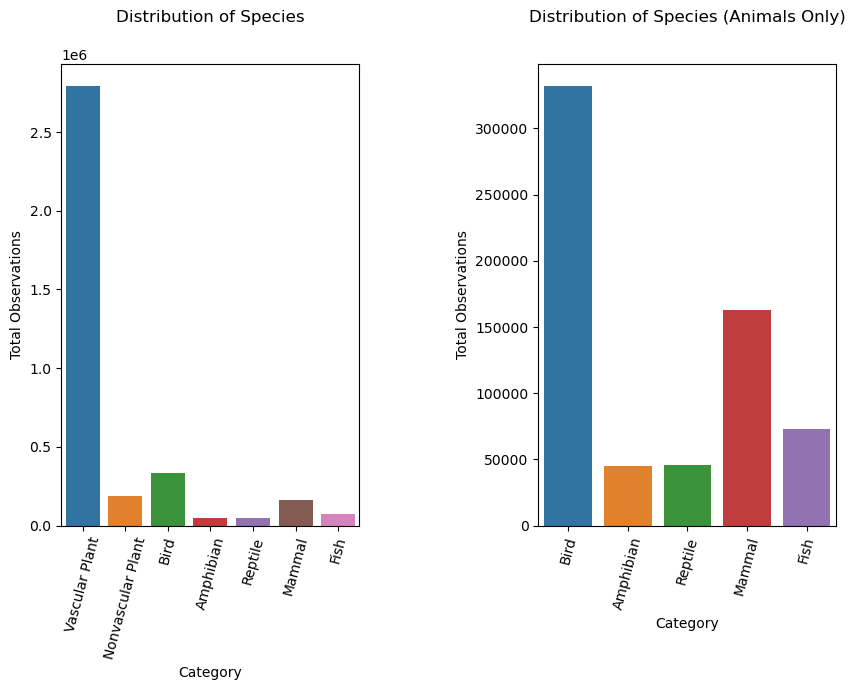

In [65]:
plt.figure(figsize=(10,6))
plt.subplots_adjust(wspace=.6)

plt.subplot(1, 2, 1)
sns.barplot(data= all_df,
            x= 'category',
            y= 'observations',
            hue= 'category',
            estimator= 'sum',
            errorbar= None)

plt.title('Distribution of Species', pad=30)
plt.xlabel('Category')
plt.xticks(rotation= 75)
plt.ylabel('Total Observations')

plt.subplot(1, 2, 2)
sns.barplot(data= all_df[~all_df['category'].isin(['Vascular Plant', 'Nonvascular Plant'])],
            x= 'category',
            y= 'observations',
            hue= 'category',
            estimator= 'sum',
            errorbar= None)

plt.title('Distribution of Species (Animals Only)', pad=30)
plt.xlabel('Category')
plt.xticks(rotation= 75)
plt.ylabel('Total Observations')

plt.show()
plt.close('all')

## Conclusion